<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">04. Approach A vs B Comparison</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Comparing two area-averaging approaches for regional Rx5day: Approach A: Rx5day computed per grid cell first, then area-averaged across region. Approach B: Daily precipitation area-averaged across region first, then Rx5day computed from that regional daily series. Both Approaches tested against CWC regional damage data to select the most appropriate method for f(R) fitting and subsequent analysis (Section 3.2 of dissertation).</p>
</div>

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import glob
import os

ERA5_DIR = '/data/oacd/obs/ERA5/'
OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'

LAT_MAX, LAT_MIN = 37, 5
LON_MIN, LON_MAX = 67, 99

YEAR_START = 1981
YEAR_END = 2023

JJAS = [6, 7, 8, 9]

print('Configuration set')

Configuration set


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 1: Load Approach A ERA5 Regional Series</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Already computed in 03_regional_masks_and_approachA - load from disk.</p>
</div>

In [2]:
# Load the already-computed Approach A ERA5 regional Rx5day series
# (computed per grid cell first, then area-averaged)
rx5day_era5_approachA = xr.open_dataset(OUTPUT_DIR + 'rx5day_era5_regional.nc')['rx5day']

print('Approach A ERA5 regional Rx5day loaded:')
print(rx5day_era5_approachA)
print(f'\nMean per region: {rx5day_era5_approachA.mean(dim="year").values}')

Approach A ERA5 regional Rx5day loaded:
<xarray.DataArray 'rx5day' (year: 43, region: 4)> Size: 1kB
[172 values with dtype=float64]
Coordinates:
    number   int64 8B ...
    abbrevs  (region) <U3 48B ...
    names    (region) <U19 304B ...
  * region   (region) <U19 304B 'Central_India' ... 'Western_Ghats'
  * year     (year) int64 344B 1981 1982 1983 1984 1985 ... 2020 2021 2022 2023

Mean per region: [191.32656007 160.14480255 273.08011985 172.77437233]


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 2: Compute Approach B ERA5 Regional Series</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Area-average daily precipitation across each region FIRST, then compute Rx5day from that regional daily time series. Requires re-reading raw ERA5 files.</p>
</div>

In [6]:
import geopandas as gpd
import regionmask
import geopandas as gpd
import regionmask

# Reload GADM state boundaries and build region masks
# (same as 03_regional_masks_and_approachA.ipynb -- reproduced here so this
# notebook is self-contained and can be run independently)
path = "/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/data/gadm/gadm41_IND.gpkg"
gdf = gpd.read_file(path, layer="ADM_ADM_1")
gdf_clean = gdf.dissolve(by="NAME_1")

region_states = {
    'Western_Ghats': ['Kerala', 'Karnataka', 'Goa', 'Maharashtra'],
    'Central_India': ['Madhya Pradesh', 'Chhattisgarh', 'Odisha', 'Jharkhand'],
    'Indo_Gangetic_Plain': ['Uttar Pradesh', 'Bihar', 'West Bengal', 'Punjab', 'Haryana'],
    'Northeast': ['Assam', 'Meghalaya', 'Arunachal Pradesh', 'Tripura']
}

state_to_region = {state: region for region, states in region_states.items() for state in states}
gdf_clean['region'] = gdf_clean.index.map(state_to_region)
gdf_regions = gdf_clean[gdf_clean['region'].notna()].dissolve(by='region')

region_names = gdf_regions.index.tolist()
regions_mask_obj = regionmask.Regions(
    gdf_regions.geometry.tolist(),
    names=region_names,
    abbrevs=[r[:3] for r in region_names]
)

print('Region masks built successfully')
print(f'Regions: {region_names}')

Region masks built successfully
Regions: ['Central_India', 'Indo_Gangetic_Plain', 'Northeast', 'Western_Ghats']


In [7]:
# Find ERA5 files covering 1981-2023
all_files = sorted(glob.glob(os.path.join(ERA5_DIR, 'combined_*.nc')))
needed_files = []
for f in all_files:
    basename = os.path.basename(f)
    start_yr = int(basename.split('_')[1])
    end_yr = int(basename.split('_')[2].replace('.nc', ''))
    if start_yr <= YEAR_END and end_yr >= YEAR_START:
        needed_files.append(f)

print(f'Found {len(needed_files)} ERA5 files needed')

def compute_approach_b_one_file(filepath, regions_mask_obj):
    """
    Approach B: area-average daily precipitation across each region FIRST,
    then compute JJAS Rx5day from that regional daily time series.

    Parameters
    ----------
    filepath : str
    regions_mask_obj : regionmask.Regions object

    Returns
    -------
    rx5day_b : xr.DataArray, shape (year, region)
    """
    print(f'  Opening {os.path.basename(filepath)}...')
    ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})

    # Collapse redundant time dimension
    pr = ds['tp'].max(dim='time')

    # Cut to India domain immediately
    pr_india = pr.sel(latitude=slice(LAT_MAX, LAT_MIN), longitude=slice(LON_MIN, LON_MAX))

    # Convert to mm
    pr_india = pr_india * 1000

    # Compute ERA5 fractional mask on this file's grid
    lat = pr_india.latitude.values
    lon = pr_india.longitude.values
    frac_overlap = regions_mask_obj.mask_3D_frac_approx(lon, lat)

    # Compute India subset into memory
    print(f'  Computing India subset...')
    pr_india = pr_india.compute()
    ds.close()

    # Approach B: area-average daily precip across each region FIRST
    # Rename dims to match frac_overlap
    pr_india = pr_india.rename({'latitude': 'lat', 'longitude': 'lon'})

    # Compute weighted regional daily mean for each day
    weight_total = frac_overlap.sum(dim=['lat', 'lon'])
    regional_daily = (pr_india * frac_overlap).sum(dim=['lat', 'lon']) / weight_total
    # regional_daily shape: (valid_time, region)

    # Filter to JJAS and required years
    regional_daily_jjas = regional_daily.sel(
        valid_time=regional_daily.valid_time.dt.month.isin(JJAS)
    )
    regional_daily_jjas = regional_daily_jjas.sel(
        valid_time=regional_daily_jjas.valid_time.dt.year.isin(range(YEAR_START, YEAR_END + 1))
    )

    if len(regional_daily_jjas.valid_time) == 0:
        return None

    # Rx5day: group by year FIRST to avoid year-boundary contamination
    def _rx5day_one_year(group):
        return group.rolling(valid_time=5, min_periods=5).sum().max(dim='valid_time')

    rx5day_b = regional_daily_jjas.groupby('valid_time.year').map(_rx5day_one_year)

    years_present = rx5day_b.year.values
    print(f'  Done: years {years_present[0]}-{years_present[-1]}, '
          f'mean = {float(rx5day_b.mean()):.1f} mm')

    return rx5day_b

print('Approach B function defined')

Found 9 ERA5 files needed
Approach B function defined


In [8]:
# Run Approach B extraction across all needed ERA5 files
print('Computing Approach B ERA5 JJAS Rx5day: 1981-2023\n')

all_b = []
for filepath in needed_files:
    result = compute_approach_b_one_file(filepath, regions_mask_obj)
    if result is not None:
        all_b.append(result)

# Join across files
rx5day_era5_approachB = xr.concat(all_b, dim='year')
rx5day_era5_approachB = rx5day_era5_approachB.sel(year=slice(YEAR_START, YEAR_END))

print(f'\nFinal shape: {dict(rx5day_era5_approachB.sizes)}')
print(f'\nMean per region (Approach B):')
print(rx5day_era5_approachB.mean(dim='year').values)

# Save to disk
rx5day_era5_approachB.name = 'rx5day'
rx5day_era5_approachB.to_netcdf(OUTPUT_DIR + 'rx5day_era5_approachB_regional.nc')
print('\nSaved rx5day_era5_approachB_regional.nc')

Computing Approach B ERA5 JJAS Rx5day: 1981-2023

  Opening combined_1980_1984.nc...


/tmp/ipykernel_1259593/593970443.py:28: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1259593/593970443.py:28: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1259593/593970443.py:28: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})


  Computing India subset...
  Done: years 1981-1984, mean = 117.9 mm
  Opening combined_1985_1989.nc...


/tmp/ipykernel_1259593/593970443.py:28: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1259593/593970443.py:28: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1259593/593970443.py:28: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})


  Computing India subset...
  Done: years 1985-1989, mean = 130.9 mm
  Opening combined_1990_1994.nc...


...

  Computing India subset...
  Done: years 2010-2014, mean = 127.2 mm
  Opening combined_2015_2019.nc...


/tmp/ipykernel_1259593/593970443.py:28: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1259593/593970443.py:28: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1259593/593970443.py:28: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})


  Computing India subset...
  Done: years 2015-2019, mean = 128.6 mm
  Opening combined_2020_2024.nc...


/tmp/ipykernel_1259593/593970443.py:28: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1259593/593970443.py:28: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1259593/593970443.py:28: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})


  Computing India subset...
  Done: years 2020-2023, mean = 132.9 mm

Final shape: {'year': 43, 'region': 4}

Mean per region (Approach B):
[108.07657062  95.19955026 201.06977653 116.6621133 ]

Saved rx5day_era5_approachB_regional.nc


In [9]:
# Load already-computed Approach B result (see cell above for original computation)
rx5day_era5_approachB = xr.open_dataset(OUTPUT_DIR + 'rx5day_era5_approachB_regional.nc')['rx5day']
print('Approach B loaded from disk')

Approach B loaded from disk


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 3: Compare Approach A vs B</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Plot both time series per region and compare means. Comparison against CWC damage data follows in Part 4.</p>
</div>

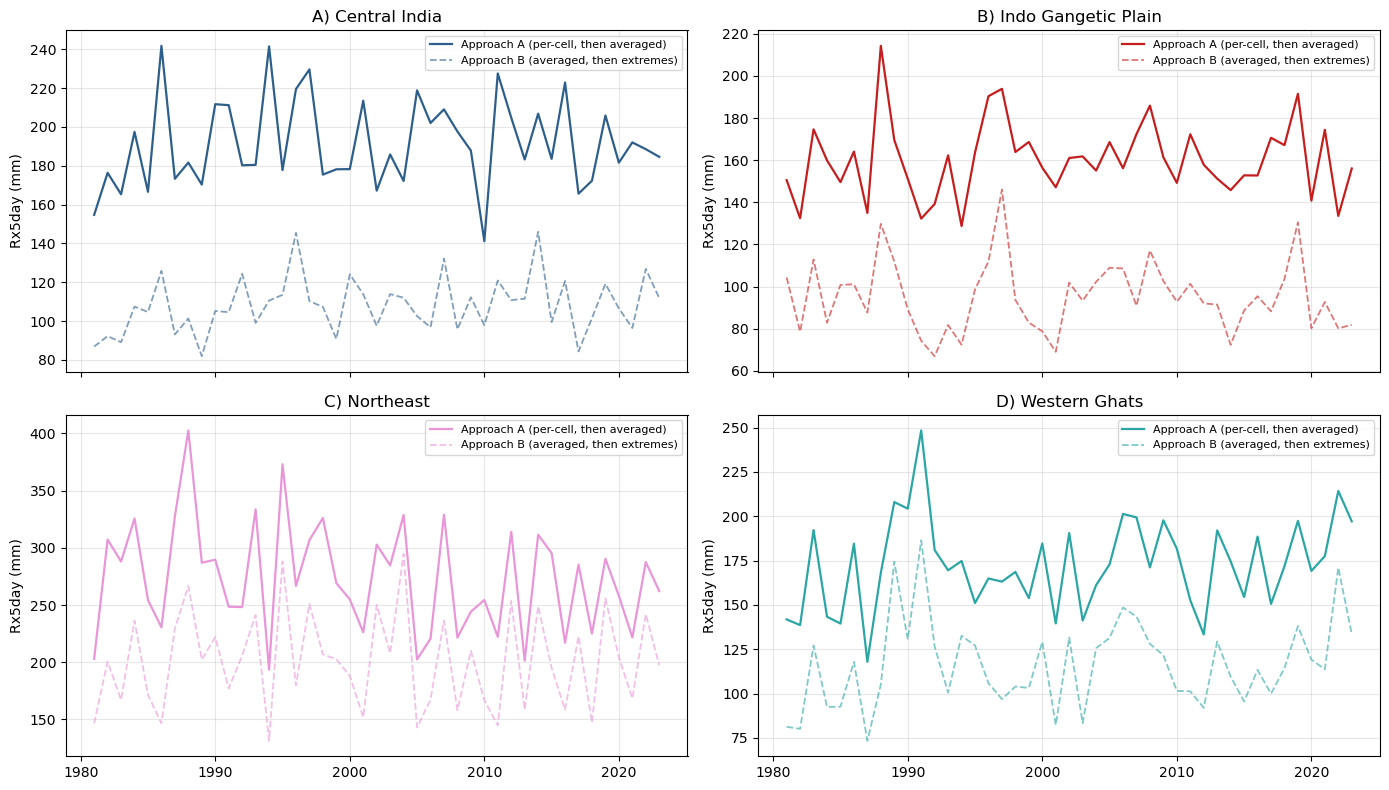

Approach A/B comparison figure saved


In [11]:
import matplotlib.pyplot as plt

REGION_COLORS = {
    'Central_India': '#2E5F8A',
    'Indo_Gangetic_Plain': '#C41E1E',
    'Northeast': '#E896D8',
    'Western_Ghats': '#2CA6A4'
}

region_names_ordered = ['Central_India', 'Indo_Gangetic_Plain', 'Northeast', 'Western_Ghats']
panel_labels = ['A)', 'B)', 'C)', 'D)']
years = rx5day_era5_approachA.year.values

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, region_name in enumerate(region_names_ordered):
    ax = axes[i]
    color = REGION_COLORS[region_name]

    a_series = rx5day_era5_approachA.isel(region=i).values
    b_series = rx5day_era5_approachB.isel(region=i).values

    ax.plot(years, a_series, label='Approach A (per-cell, then averaged)', color=color, linewidth=1.6)
    ax.plot(years, b_series, label='Approach B (averaged, then extremes)', color=color,
            linewidth=1.3, linestyle='--', alpha=0.6)

    ax.set_title(f'{panel_labels[i]} {region_name.replace("_", " ")}', fontsize=12, loc='center')
    ax.set_ylabel('Rx5day (mm)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure_approachAB_comparison_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Approach A/B comparison figure saved')

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 4: Select Approach Based on CWC Damage Correlation</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Correlate both Approach A and Approach B regional Rx5day (JJAS) against CWC regional total damages to determine which spatial-averaging method better predicts observed flood damage. An initial check uses the 2000-2020 window; the selection criterion reported in the dissertation (Table 3) uses the fuller 1981-2020 window, with Central India's window restricted to 2001-2020 to avoid contamination from the 2000 Jharkhand-Bihar boundary change.</p>
</div>

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <p style="color: #cce0ff; margin: 0; font-size: 13px;">Initial check using the 2000-2020 CWC window. Superseded by the 1981-2020 result below (cell with the consolidated selection table), which is the one reported in Table 3.</p>
</div>

In [14]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr

# region order confirmed earlier: Central_India, Indo_Gangetic_Plain, Northeast, Western_Ghats
REGION_ORDER = ['Central_India', 'Indo_Gangetic_Plain', 'Northeast', 'Western_Ghats']

rx5day_A = rx5day_era5_approachA.assign_coords(region=REGION_ORDER)
rx5day_B = rx5day_era5_approachB.assign_coords(region=REGION_ORDER)

cwc = pd.read_csv(OUTPUT_DIR + 'cwc_regional_aggregated_FINAL_2000_2020_real2022.csv')

results = []
for region in REGION_ORDER:
    cwc_r = cwc[cwc.region == region].set_index('year')['regional_total_cr_real_2022']
    years = cwc_r.index.values

    rain_A = rx5day_A.sel(region=region, year=years).values
    rain_B = rx5day_B.sel(region=region, year=years).values
    damage = cwc_r.values
    log_damage = np.log1p(damage)  # damage is heavy-tailed; log helps for Pearson

    pear_A, _ = pearsonr(rain_A, log_damage)
    pear_B, _ = pearsonr(rain_B, log_damage)
    spear_A, p_A = spearmanr(rain_A, damage)
    spear_B, p_B = spearmanr(rain_B, damage)

    results.append({
        'region': region,
        'pearson_logdamage_A': round(pear_A, 3), 'pearson_logdamage_B': round(pear_B, 3),
        'spearman_A': round(spear_A, 3), 'spearman_B': round(spear_B, 3),
        'p_A': round(p_A, 3), 'p_B': round(p_B, 3),
    })

results_df = pd.DataFrame(results)
print(results_df)
print(f"\nMean Spearman A: {results_df.spearman_A.mean():.3f}, B: {results_df.spearman_B.mean():.3f}")

print(f"\n{'Region':<22} {'Spearman A':<12} {'p-value A':<12} {'Spearman B':<12} {'p-value B'}")
for row in results:
    print(f"{row['region']:<22} {row['spearman_A']:<12} {row['p_A']:<12} {row['spearman_B']:<12} {row['p_B']}")

                region  pearson_logdamage_A  pearson_logdamage_B  spearman_A  \
0        Central_India                0.443               -0.025       0.527   
1  Indo_Gangetic_Plain                0.116               -0.251       0.204   
2            Northeast                0.449                0.419       0.473   
3        Western_Ghats                0.324                0.101       0.478   

   spearman_B    p_A    p_B  
0       0.016  0.014  0.947  
1      -0.336  0.375  0.136  
2       0.429  0.030  0.053  
3       0.228  0.029  0.320  

Mean Spearman A: 0.420, B: 0.084

Region                 Spearman A   p-value A    Spearman B   p-value B
Central_India          0.527        0.014        0.016        0.947
Indo_Gangetic_Plain    0.204        0.375        -0.336       0.136
Northeast              0.473        0.03         0.429        0.053
Western_Ghats          0.478        0.029        0.228        0.32


In [15]:
# Deflate the EXTENDED correlation file (1981-2020, used only in notebook 04_approach_ab_comparison).
# Note: this file predates today's reporting-completeness fix. It has no n_reporting/
# pct_states_reporting/data_quality_flag columns, and its exact aggregation source is
# untraced (not built in any notebook currently on hand). Deflating as-is; NOT attempting
# to retroactively verify or fix its underlying completeness, since the original per-state
# inputs aren't available. 

deflator_long = pd.read_csv(OUTPUT_DIR + 'gdp_deflator_national.csv')
cwc_ext = pd.read_csv(OUTPUT_DIR + 'cwc_regional_aggregated_EXTENDED_for_correlation.csv')

cwc_ext_deflated = cwc_ext.merge(deflator_long, on='year', how='left')

n_missing_deflator = cwc_ext_deflated['deflator_index'].isna().sum()
print(f"Rows with no deflator match: {n_missing_deflator}")  # expect 0, given full 1981-2020 coverage

cwc_ext_deflated['regional_total_cr_real_2022'] = (
    cwc_ext_deflated['regional_total_cr'] * (100 / cwc_ext_deflated['deflator_index'])
)

out_path = OUTPUT_DIR + 'cwc_regional_aggregated_EXTENDED_for_correlation_real2022.csv'
cwc_ext_deflated.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(cwc_ext_deflated.groupby('region')['year'].agg(['min', 'max', 'count']))

Rows with no deflator match: 0
Saved: /home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/cwc_regional_aggregated_EXTENDED_for_correlation_real2022.csv
                      min   max  count
region                                
Central_India        2001  2020     20
Indo_Gangetic_Plain  1981  2020     40
Northeast            1981  2020     40
Western_Ghats        1981  2020     40


In [17]:
# Consolidated Approach A vs B selection criterion: Spearman correlation with CWC damage
summary_records = []
for region in REGION_ORDER:
    cwc_r = cwc_ext_deflated[cwc_ext_deflated.region == region].set_index('year')['regional_total_cr_real_2022']
    years_r = cwc_r.index.values

    rain_A = rx5day_A.sel(region=region, year=years_r).values
    rain_B = rx5day_B.sel(region=region, year=years_r).values
    damage = cwc_r.values

    spear_A, p_A = spearmanr(rain_A, damage)
    spear_B, p_B = spearmanr(rain_B, damage)

    summary_records.append({
        'Region': region.replace('_', ' '),
        'N': len(years_r),
        'Spearman ρ (A)': round(spear_A, 3),
        'p-value (A)': round(p_A, 3),
        'Spearman ρ (B)': round(spear_B, 3),
        'p-value (B)': round(p_B, 3)
    })

summary_table = pd.DataFrame(summary_records)
mean_row = pd.DataFrame([{
    'Region': 'Mean (all regions)', 'N': '-',
    'Spearman ρ (A)': round(summary_table['Spearman ρ (A)'].mean(), 3), 'p-value (A)': '-',
    'Spearman ρ (B)': round(summary_table['Spearman ρ (B)'].mean(), 3), 'p-value (B)': '-'
}])
summary_table = pd.concat([summary_table, mean_row], ignore_index=True)

summary_table.to_csv(OUTPUT_DIR + 'approachAB_selection_table.csv', index=False)
print(summary_table.to_string(index=False))

             Region  N  Spearman ρ (A) p-value (A)  Spearman ρ (B) p-value (B)
      Central India 20           0.495       0.027           0.137       0.565
Indo Gangetic Plain 40           0.000       0.998          -0.224       0.164
          Northeast 40           0.260       0.105           0.280        0.08
      Western Ghats 40           0.454       0.003           0.294       0.066
 Mean (all regions)  -           0.302           -           0.122           -


In [18]:
for region in REGION_ORDER:
    sub = cwc_ext_deflated[cwc_ext_deflated.region == region]
    n_total = len(sub)
    n_valid = sub['regional_total_cr_real_2022'].notna().sum()
    print(f"{region}: {n_total} total year-rows, {n_valid} with valid damage, "
          f"years range {sub.year.min()}-{sub.year.max()}")

Central_India: 20 total year-rows, 20 with valid damage, years range 2001-2020
Indo_Gangetic_Plain: 40 total year-rows, 40 with valid damage, years range 1981-2020
Northeast: 40 total year-rows, 40 with valid damage, years range 1981-2020
Western_Ghats: 40 total year-rows, 40 with valid damage, years range 1981-2020
